# Black-Scholes-Merton (1973) index level at maturity

## KeyPoints of BSM Model:
- In the BSM model, the index level at maturity is a random variable, given with z being a standard normally distributed random variable.
- The Black-Scholes model, aka the Black-Scholes-Merton (BSM) model, is a differential equation widely used to price options contracts.
- The Black-Scholes model requires five input variables: the strike price of an option, the current stock price, the time to expiration, the risk-free rate, and the volatility.
- Though usually accurate, the Black-Scholes model makes certain assumptions that can lead to predictions that deviate from the real-world results.
- The standard BSM model is only used to price European options, as it does not take into account that American options could be exercised before the expiration date.

In [1]:
import numpy as np
from numpy import exp,maximum

In [2]:
pip install pandas_datareader

  Using cached pandas_datareader-0.10.0-py3-none-any.whl (109 kB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Monte Carlo valuation of European call option in Black-Scholes-Merton model

import numpy as np
# Parameter Values
S0 = 100. # initial index level
K = 105. # strike price
T = 1.0 # time-to-maturity
r = 0.05 # riskless short rate
sigma = 0.2 # volatility
I = 100000 # number of simulations

In [4]:
# Valuation Algorithm
z = np.random.standard_normal(I) # pseudorandom numbers
ST = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * z)

# index values at maturity
hT = np.maximum(ST - K, 0) # inner values at maturity
C0 = np.exp(-r * T) * np.sum(hT) / I # Monte Carlo estimator

# Result Output
print("Value of the European Call Option %5.3f" % C0)

Value of the European Call Option 8.079


# Getting Data from WEB

In [5]:
import pandas as pd
import datetime as dt
import pandas_datareader.data as web

In [6]:
# https://pydata.github.io/pandas-datareader/remote_data.html

# Getting Data from Stooq
start= dt.datetime(2020,1,1)
end =  dt.datetime(2022,1,1)

# https://stooq.com/q/d/?s=es.f
# ^SPX: S&P 500 E-Mini 

f = web.DataReader('^SPX', 'stooq',start,end)
f.head()

,Open,High,Low,Close,Volume
Date,,,,,
2021-12-31,4775.21,4786.83,4765.75,4766.18,1339318824
2021-12-30,4794.23,4808.93,4775.33,4778.73,1353236996
2021-12-29,4788.64,4804.06,4778.08,4793.06,1365873126
2021-12-28,4795.49,4807.02,4780.04,4786.35,1432143549
2021-12-27,4733.99,4791.49,4733.99,4791.19,1503734418


In [7]:
# Getting Data from Yahoo Finance
import yfinance as yf
company = 'GOOG'

# Define a start date and End Date
start = dt.datetime(2009,3,14)
end =  dt.datetime(2014,4,14)

# Read Stock Price Data 
datagoog = yf.download(company, start , end)

datagoog.tail()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-04-07,26.962973,27.348913,26.285334,26.833828,26.833828,88033033
2014-04-08,27.055719,27.674021,27.006353,27.669035,27.669035,63024560
2014-04-09,27.904388,28.191101,27.571802,28.129770,28.129770,66616395
2014-04-10,28.172651,28.172651,26.921087,26.973444,26.973444,80737057
2014-04-11,26.554594,26.926073,26.254417,26.457361,26.457361,78496923


## Indian Stock Data

In [8]:
stocks = ["AXISBANK.NS", "HDFCBANK.NS", "ICICIBANK.NS" ,"INDUSINDBK.NS","KOTAKBANK.NS", "SBIN.NS", "YESBANK.NS"]
start = dt.datetime(2018,1,1)
end = dt.datetime(2019,7,17)
data = yf.download(stocks, start=start, end=end)
data

[*********************100%***********************]  7 of 7 completed


Adj Close                                                       \
           AXISBANK.NS  HDFCBANK.NS ICICIBANK.NS INDUSINDBK.NS KOTAKBANK.NS   
Date                                                                          
2018-01-01  563.940125   899.247742   301.323120   1582.162109   997.804932   
2018-01-02  557.956726   907.903259   300.740479   1601.746216  1001.047974   
2018-01-03  558.904114   898.350647   305.887177   1588.397949   997.954590   
2018-01-04  558.355652   901.866333   305.595856   1604.328003   998.254028   
2018-01-05  561.696350   903.660339   303.847900   1654.603516  1000.898254   
...                ...          ...          ...           ...          ...   
2019-07-10  768.080872  1172.949341   425.002899   1460.399658  1473.435669   
2019-07-11  765.235229  1181.984253   420.712402   1513.424805  1482.520752   
2019-07-12  754.651306  1175.478027   421.205566   1482.248169  1482.021484   
2019-07-15  748.610474  1175.895630   416.520538   1448.469116  1506.444580   
2019-07-16  759.893311  1174.152344   418.789062   1446.603394  1499.801880   

                                         Close                            ...  \
               SBIN.NS  YESBANK.NS AXISBANK.NS  HDFCBANK.NS ICICIBANK.NS  ...   
Date                                                                      ...   
2018-01-01  299.614838  301.846222  565.500000   927.250000   310.299988  ...   
2018-01-02  295.858643  300.928894  559.500000   936.174988   309.700012  ...   
2018-01-03  295.468414  304.984406  560.450012   926.325012   315.000000  ...   
2018-01-04  300.980682  306.191406  559.900024   929.950012   314.700012  ...   
2018-01-05  298.883087  321.399597  563.250000   931.799988   312.899994  ...   
...                ...         ...         ...          ...          ...  ...   
2019-07-10  345.566833   93.000000  769.250000  1194.375000   430.899994  ...   
2019-07-11  354.347443   92.449997  766.400024  1203.574951   426.549988  ...   
2019-07-12  354.737701   94.199997  755.799988  1196.949951   427.049988  ...   
2019-07-15  351.274200   93.199997  749.750000  1197.375000   422.299988  ...   
2019-07-16  355.469421  103.849998  761.049988  1195.599976   424.600006  ...   

                   Open                              Volume              \
           KOTAKBANK.NS     SBIN.NS  YESBANK.NS AXISBANK.NS HDFCBANK.NS   
Date                                                                      
2018-01-01  1011.849976  310.600006  315.500000     6943234     3290258   
2018-01-02  1001.000000  309.000000  313.399994     6292268     2388158   
2018-01-03  1002.599976  305.299988  312.000000     3990149     2265644   
2018-01-04  1001.000000  304.500000  316.000000     2766664     1186888   
2018-01-05  1002.500000  311.399994  317.500000     3249056     1435434   
...                 ...         ...         ...         ...         ...   
2019-07-10  1463.000000  360.549988   92.150002     5814417     5784574   
2019-07-11  1479.000000  358.500000   94.000000     7111401     4548798   
2019-07-12  1486.949951  363.000000   93.250000     8552548     4488136   
2019-07-15  1489.000000  364.100006   95.000000     6350785     4116592   
2019-07-16  1508.000000  358.500000   94.000000     6170479     6385284   

                                                                         
           ICICIBANK.NS INDUSINDBK.NS KOTAKBANK.NS   SBIN.NS YESBANK.NS  
Date                                                                     
2018-01-01      7739502        771099      1317415  12182400    4019878  
2018-01-02      7046560       1392045      1072207  14797364    5224976  
2018-01-03      8898342       1120860       884021  13857373    5672263  
2018-01-04      6385367        747232       783950  24517099    5667580  
2018-01-05      6366054       1134406      2147402  14580575   30720675  
...                 ...           ...          ...       ...        ...  
2019-07-10     16494282       3222571      2180732  18

In [9]:
import pandas as pd

df = pd.DataFrame(data) 

# saving the dataframe 
# df.to_csv('BANKING STOCK.csv')

# Plotting the Data

In [10]:
import matplotlib.pyplot

In [11]:
datagoog_df = pd.DataFrame(datagoog)

In [12]:
# Compute the daily log returns of the stock prices. The log returns are computed as the natural logarithm 
# of the daily closing price divided by the previous day's closing price. 

# compute the daily log returns
datagoog_df['Log_Ret'] = np.log(datagoog_df['Close'] / datagoog_df['Close'].shift(1))

In [13]:
# Compute the rolling standard deviation of the log returns using the rolling method and the std method. 
# The rolling window size can be adjusted depending on your preference. For example, if you want to compute 
# the annualized volatility using daily data, you can use a window size of 252 trading days. 

# compute the rolling standard deviation of the log returns
datagoog_df['Volatility'] = datagoog_df['Log_Ret'].rolling(window=252).std() * np.sqrt(252)

In [13]:
datagoog_df.head()

,Open,High,Low,Close,Adj Close,Volume,Log_Ret,Volatility
Date,,,,,,,,
2009-03-16,8.119317,8.212468,7.935008,7.962405,7.962405,198613673,NaN,NaN
2009-03-17,7.974609,8.352194,7.947461,8.352194,8.352194,189206544,0.047793,NaN
2009-03-18,8.338993,8.468259,8.170624,8.296403,8.296403,201239478,-0.006702,NaN
2009-03-19,8.261036,8.368632,8.153937,8.217698,8.217698,165064391,-0.009532,NaN
2009-03-20,8.226664,8.293663,8.128034,8.223178,8.223178,190226352,0.000667,NaN


array([<AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>],
      dtype=object)

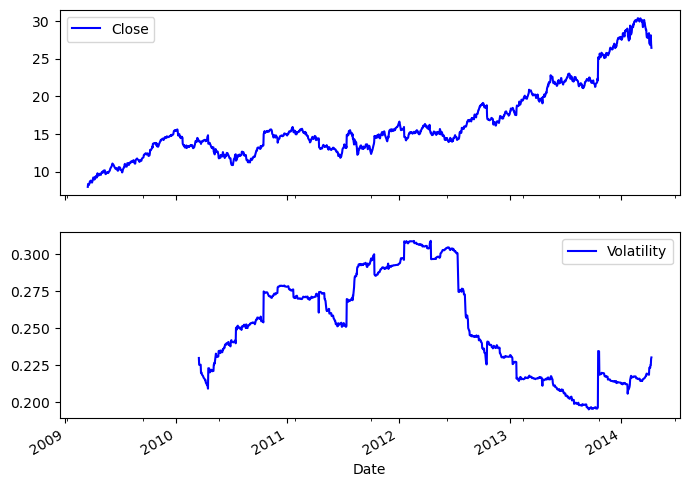

In [19]:
%matplotlib inline

datagoog_df[['Close', 'Volatility']].plot(subplots=True, color='blue',figsize=(8, 6))


# The resulting plot will have the stock price on the left and the volatility on the right. 
# The stock price subplot will show the daily closing price of the stock over time, while the volatility 
# subplot will show the computed rolling standard deviation of the stock's daily log returns (which is 
# an estimate of the volatility of the stock). The x-axis of both subplots will show the time 
# (e.g., daily, weekly, monthly) and the y-axis will show the stock price and volatility values, respectively.

# By plotting the stock price and volatility side by side, you can visually compare the two metrics and 
# look for any patterns or correlations between them. For example, you might expect to see higher volatility 
# during periods of market turbulence or significant news events.

In [15]:
# https://medium.datadriveninvestor.com/how-to-generate-a-graph-for-a-stock-price-with-python-yahoo-finance-and-plotly-7f3a36f5ce7e

import plotly.graph_objs as go
import yfinance as yf

choice = input("Write a stock symbol: ")
choice = choice.upper()
data = yf.download(tickers=choice, period = '5d', interval = '15m', rounding= True)

fig = go.Figure()

fig.add_trace(go.Candlestick(x=data.index,open = data['Open'], high=data['High'], low=data['Low'], close=data['Close'], name = 'market data'))

fig.update_layout(title = choice + ' share price', yaxis_title = 'Stock Price (USD)')

fig.update_xaxes( rangeslider_visible=True,
        rangeselector=dict(
            buttons=list([
                dict(count=15, label='15m', step="minute", stepmode="backward"),
                dict(count=45, label='45m', step="minute", stepmode="backward"),
                dict(count=1, label='1h', step="hour", stepmode="backward"),
                dict(count=6, label='6h', step="hour", stepmode="backward"),
                dict(step="all")
            ]))
)

fig.show()

Write a stock symbol: MARUTI.NS
[*********************100%***********************]  1 of 1 completed
